In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Single objective

Max folder: 295


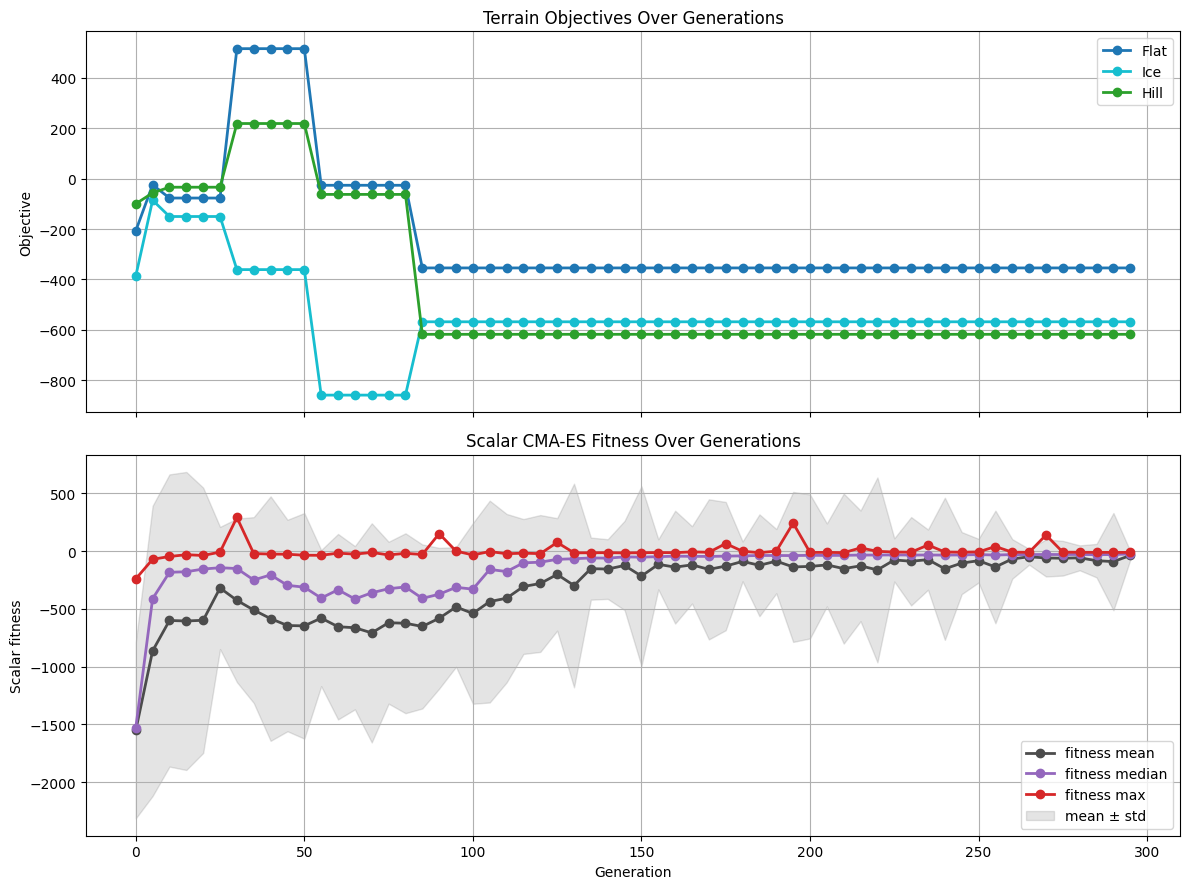

In [8]:
# Plot all three terrain objectives together and scalar CMA-ES fitness from f.npy.
# In notebooks on macOS, AsyncVectorEnv can fail with EOFError, so evaluate sequentially.
import gymnasium as gym
from final_project_train import FinalWorld

path = "results/2026-05-15_19-10-13_final_test"
step = 5
n_repeats = 2
n_steps = 500

max_folder = max(int(d) for d in os.listdir(path) if d.isdigit())
print(f"Max folder: {max_folder}")

world = FinalWorld()

def eval_env_seq(world, env_id, world_file, n_repeats=2, n_steps=500):
    rewards = []
    for rep in range(n_repeats):
        env = gym.make(env_id, robot_path=world_file, max_episode_steps=n_steps)
        obs, _ = env.reset(seed=rep)
        world.controller.reset_controller(batch_size=1)
        total = 0.0
        done = False
        while not done:
            ctrl_obs = world.sensor_fn(obs) if world.sensor_fn is not None else obs
            action = world.controller.get_action(ctrl_obs)
            if getattr(action, "ndim", 0) > 1:
                action = action.squeeze(0)
            obs, reward, terminated, truncated, _ = env.step(action)
            total += reward
            done = terminated or truncated
        env.close()
        rewards.append(total)
    return float(np.mean(rewards))

terrain_scores = []
scalar_mean = []
scalar_max = []
scalar_min = []
scalar_median = []
scalar_std = []
generations = []

for i in range(0, max_folder + 1, step):
    x_path = f"{path}/{i}/x_best.npy"
    f_path = f"{path}/{i}/f.npy"
    if not (os.path.isfile(x_path) and os.path.isfile(f_path)):
        continue
    x_best = np.load(x_path, allow_pickle=True)
    f = np.load(f_path, allow_pickle=True)
    world.update_robot_xml(x_best)
    fitness = np.array([
        eval_env_seq(world, "FlatEnv-v0", world.flat_world_file, n_repeats=n_repeats, n_steps=n_steps),
        eval_env_seq(world, "IceEnv-v0", world.ice_world_file, n_repeats=n_repeats, n_steps=n_steps),
        eval_env_seq(world, "HillEnv-v0", world.hill_world_file, n_repeats=n_repeats, n_steps=n_steps),
    ])
    terrain_scores.append(fitness)
    scalar_mean.append(np.mean(f))
    scalar_max.append(np.max(f))
    scalar_min.append(np.min(f))
    scalar_median.append(np.median(f))
    scalar_std.append(np.std(f))
    generations.append(i)

terrain_scores = np.asarray(terrain_scores, dtype=float)
scalar_mean = np.asarray(scalar_mean, dtype=float)
scalar_max = np.asarray(scalar_max, dtype=float)
scalar_min = np.asarray(scalar_min, dtype=float)
scalar_median = np.asarray(scalar_median, dtype=float)
scalar_std = np.asarray(scalar_std, dtype=float)
generations = np.asarray(generations)
labels = ["Flat", "Ice", "Hill"]
colors = ["#1f77b4", "#17becf", "#2ca02c"]

fig, axs = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

for j, label in enumerate(labels):
    axs[0].plot(generations, terrain_scores[:, j], marker="o", linewidth=2, color=colors[j], label=label)
axs[0].set_title("Terrain Objectives Over Generations")
axs[0].set_ylabel("Objective")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(generations, scalar_mean, marker="o", linewidth=2, color="#4c4c4c", label="fitness mean")
axs[1].plot(generations, scalar_median, marker="o", linewidth=2, color="#9467bd", label="fitness median")
axs[1].plot(generations, scalar_max, marker="o", linewidth=2, color="#d62728", label="fitness max")
# axs[1].plot(generations, scalar_min, marker="o", linewidth=2, color="#ff7f0e", label="fitness min")
axs[1].fill_between(generations, scalar_mean - scalar_std, scalar_mean + scalar_std, color="#4c4c4c", alpha=0.15, label="mean ± std")
axs[1].set_title("Scalar CMA-ES Fitness Over Generations")
axs[1].set_xlabel("Generation")
axs[1].set_ylabel("Scalar fitness")
axs[1].legend()
axs[1].grid(True)

fig.tight_layout()


In [ ]:
# plot mean and max of both objectives in f over generations. 
# For that read folders with f_best = np.load("results/20260401_113146_nsga_ckpts/i/f.npy") 
# for i in range(0, 600, 10) and plot the mean and max of f on y and generations on x on two subplots.
flat_mean = []
flat_max = []
flat_std = []


path = "results/2026-05-07_12-06-36_final_test"

max_folder = max([int(d) for d in os.listdir(path) if d.isdigit()])
print(f"Max folder: {max_folder}")

fig,axs = plt.subplots(1,1, figsize=(8, 6))
for i in range(9, max_folder+1, 10):
    f = np.load(f"{path}/{i}/f.npy")
    flat_mean.append(np.mean(f, axis=0))
    flat_max.append(np.max(f, axis=0))
    
    flat_std.append(np.std(f, axis=0))

generations = np.arange(9, max_folder+1, 10)


# path = "results/2026-05-12_18-44-48_final_test"

# max_folder_2 = max([int(d) for d in os.listdir(path) if d.isdigit()])
# print(f"Max folder: {max_folder_2}")


# for i in range(0, max_folder_2+1, 5):
#     f = np.load(f"{path}/{i}/f.npy")
#     flat_mean.append(np.mean(f, axis=0))
#     flat_max.append(np.max(f, axis=0))
    
#     flat_std.append(np.std(f, axis=0))

# generations_2 = np.arange(max_folder+1, max_folder+max_folder_2+2, 5)

# generations = np.concatenate((generations, generations_2))

axs.plot(generations, flat_mean, label="Mean", color="blue")
axs.plot(generations, flat_max, label="Max", color="red")
# add trend lines for both objectives
z = np.polyfit(generations, flat_mean, 7)
p = np.poly1d(z)
axs.plot(generations, p(generations), linestyle="--", color="blue")
z = np.polyfit(generations, flat_max, 7)
p = np.poly1d(z)
axs.plot(generations, p(generations), linestyle="--", color="red")    
axs.set_ylabel("Flat Objective")
axs.legend(loc="lower right")
axs.fill_between(generations, np.array(flat_mean) - np.array(flat_std), np.array(flat_mean) + np.array(flat_std), alpha=0.2, color="blue")
axs.grid("on")
axs.set_title("Flat Objective over Generations")



fig.tight_layout()
